In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris # sklearn으로 dataset 접근시 리스트로 접근함
from sklearn.model_selection import train_test_split # train set과 test set을 분리해줌
from sklearn.linear_model import LinearRegression # 선형 회귀 분석 모델
from sklearn.metrics import mean_squared_error, r2_score # 수학공식 모아둔 패키지

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [85]:
sns.load_dataset('iris')

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [86]:
load_iris() # 딕셔너리 타입으로 나옴 (data, target, 이름들 다 포함)

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [87]:
load_iris().data # feature만 꺼낸 numpy배열

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [88]:
load_iris().data.shape # feature의 크기를 알려주는 속성
# 행이 150개 열이 4개가 있는 2차원 Numpy 배열

(150, 4)

In [89]:
iris = load_iris().data 

In [90]:
iris[0] # 첫번째 행들이 나옴

array([5.1, 3.5, 1.4, 0.2])

In [91]:
iris[:] # 전체 행

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [92]:
iris[:, 0] # 전체행, 0번째 열 (sepal_length) 선택

array([5.1, 4.9, 4.7, 4.6, 5. , 5.4, 4.6, 5. , 4.4, 4.9, 5.4, 4.8, 4.8,
       4.3, 5.8, 5.7, 5.4, 5.1, 5.7, 5.1, 5.4, 5.1, 4.6, 5.1, 4.8, 5. ,
       5. , 5.2, 5.2, 4.7, 4.8, 5.4, 5.2, 5.5, 4.9, 5. , 5.5, 4.9, 4.4,
       5.1, 5. , 4.5, 4.4, 5. , 5.1, 4.8, 5.1, 4.6, 5.3, 5. , 7. , 6.4,
       6.9, 5.5, 6.5, 5.7, 6.3, 4.9, 6.6, 5.2, 5. , 5.9, 6. , 6.1, 5.6,
       6.7, 5.6, 5.8, 6.2, 5.6, 5.9, 6.1, 6.3, 6.1, 6.4, 6.6, 6.8, 6.7,
       6. , 5.7, 5.5, 5.5, 5.8, 6. , 5.4, 6. , 6.7, 6.3, 5.6, 5.5, 5.5,
       6.1, 5.8, 5. , 5.6, 5.7, 5.7, 6.2, 5.1, 5.7, 6.3, 5.8, 7.1, 6.3,
       6.5, 7.6, 4.9, 7.3, 6.7, 7.2, 6.5, 6.4, 6.8, 5.7, 5.8, 6.4, 6.5,
       7.7, 7.7, 6. , 6.9, 5.6, 7.7, 6.3, 6.7, 7.2, 6.2, 6.1, 6.4, 7.2,
       7.4, 7.9, 6.4, 6.3, 6.1, 7.7, 6.3, 6.4, 6. , 6.9, 6.7, 6.9, 5.8,
       6.8, 6.7, 6.7, 6.3, 6.5, 6.2, 5.9])

In [93]:
X = iris[:, 0].reshape(-1,1) # 1차원에서 2차원으로 만들어줌 (데이터 학습을 위해)

In [94]:
y = iris[:,2] # 전체행, 2번째 열 (petal_length) 선택

<Axes: >

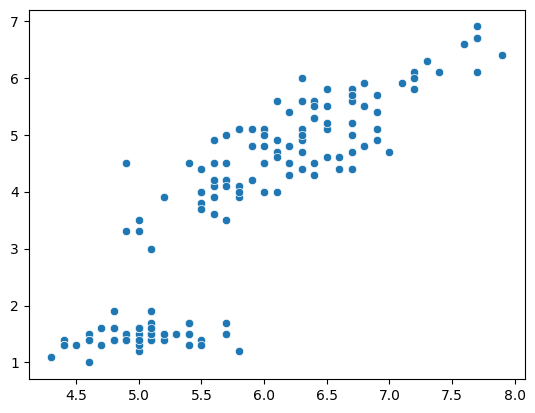

In [95]:
sns.scatterplot(x=X.flatten(),y=y) # 시각화

In [96]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [97]:
X_train.shape

(120, 1)

In [98]:
X_test.shape

(30, 1)

In [99]:
y_train.shape

(120,)

In [100]:
y_test.shape

(30,)

In [101]:
model = LinearRegression()

In [102]:
model.fit(X_train,y_train) # fit = 학습한다. x값은 2차원 y값에는 1차원 데이터가 국룰임

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
w = model.coef_[0]  # 기울기

In [104]:
b = model.intercept_   # 절편
b

np.float64(-6.927127731475698)

In [105]:
y_pred = model.predict(X_test) # x test값을 넣었을때 예측되는 y값

In [106]:
y_test[:] # 진짜 y값

array([4.7, 1.7, 6.9, 4.5, 4.8, 1.5, 3.6, 5.1, 4.5, 3.9, 5.1, 1.4, 1.3,
       1.5, 1.5, 4.7, 5.8, 3.9, 4.5, 5.6, 1.6, 4.9, 1.6, 5.6, 6.4, 5.2,
       5.8, 5.9, 1.4, 1.6])

In [107]:
y_pred # 예측된 y값

array([4.26004412, 3.52645908, 7.19438428, 4.07664786, 5.54381794,
       2.9762703 , 3.34306282, 5.7272142 , 4.44344038, 3.70985534,
       4.99362916, 1.87589274, 3.15966656, 2.059289  , 2.42608152,
       4.62683664, 4.99362916, 3.34306282, 3.52645908, 4.8102329 ,
       1.69249648, 4.26004412, 2.24268526, 4.8102329 , 7.5611768 ,
       5.36042168, 5.36042168, 5.54381794, 1.87589274, 1.87589274])

In [108]:
mse = mean_squared_error(y_test, y_pred) # mse로 모델을 평가함 값이 작을수록 좋음
r2 = r2_score(y_test, y_pred) # 1.0에 가까울수록 좋고 0.7정도면 괜찮은 모델

In [109]:
mse 

0.5960765879745179

In [110]:
r2

0.8181245472591439

In [112]:
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_line = model.predict(x_line)

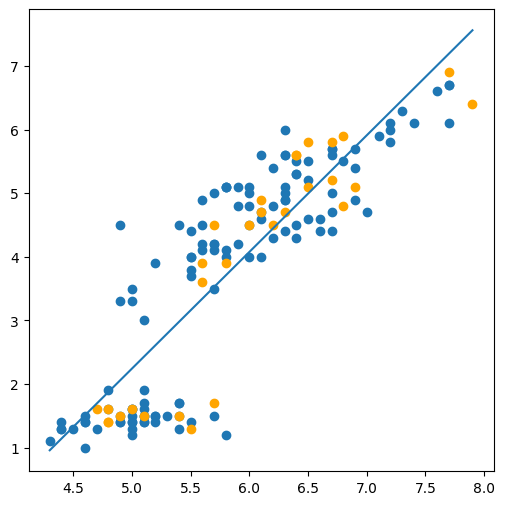

In [113]:
plt.figure(figsize=(6,6))
plt.scatter(X_train,y_train) # 원래 X_train은 2차원인데 scatterplot에서 1차원으로 받음
plt.scatter(X_test, y_test, color='orange')
plt.plot(x_line, y_line)

In [83]:
X_all = iris[:,[0,1,3]]
X_all.shape

(150, 3)

In [132]:
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(X_all,y, test_size=0.2, random_state=42)

In [133]:
model_all = LinearRegression()

In [134]:
model_all.fit(X_all_train, y_all_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [135]:
y_all_pred = model_all.predict(X_all_test)
y_all_pred

array([4.12771597, 1.882002  , 7.02565911, 4.43211007, 4.92719101,
       2.06623661, 3.84947941, 6.12949916, 5.02174454, 3.97445323,
       5.33653445, 1.44661722, 1.78143162, 1.45531704, 1.44831322,
       4.54138026, 5.75720255, 3.8103012 , 3.98534252, 5.81208439,
       1.39392486, 4.88106709, 1.77711076, 5.66533199, 5.96698503,
       6.04851788, 5.63266411, 5.99363605, 1.74012203, 1.52978798])

In [136]:
mse_all  = mean_squared_error(y_all_test, y_all_pred)
mse_all

0.1300162603138271

In [137]:
r2_all = r2_score(y_all_test, y_all_pred)
r2_all

0.9603293155857663

In [138]:
model_all.coef_

array([ 0.72281463, -0.63581649,  1.46752403])

In [119]:
df = pd.read_csv('train.csv')

In [120]:
df_t = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']].replace(0, None)

In [121]:
df_t = df_t.dropna()

In [122]:
df_t.corr()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Glucose,1.000000,0.213390,0.214293,0.600479,0.212549,0.140880,0.342942
BloodPressure,0.213390,1.000000,0.249560,0.088505,0.292520,-0.031260,0.301791
SkinThickness,0.214293,0.249560,1.000000,0.200479,0.632375,0.119519,0.182784
Insulin,0.600479,0.088505,0.200479,1.000000,0.258074,0.182614,0.196610
BMI,0.212549,0.292520,0.632375,0.258074,1.000000,0.111317,0.078956
DiabetesPedigreeFunction,0.140880,-0.031260,0.119519,0.182614,0.111317,1.000000,0.103043
Age,0.342942,0.301791,0.182784,0.196610,0.078956,0.103043,1.000000


In [123]:
X =df_t[['BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']]

In [124]:
X = df_t.drop('Glucose', axis=1) # 위에랑 이거랑 똑같이 X에 Glucose 값 빼는것
X

,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,60,33,192,24.0,0.966,33
3,88,41,170,45.3,0.507,26
4,66,36,200,38.1,0.289,21
5,50,32,88,31.0,0.248,26
6,54,25,100,25.2,0.234,23
...,...,...,...,...,...,...
636,110,24,240,45.4,0.721,54
637,90,33,29,26.8,0.731,43
638,62,41,480,40.7,0.536,21
643,74,25,293,34.9,0.385,30


In [125]:
y = df_t['Glucose']
y

0      103
3      119
4      114
5       78
6       91
      ... 
636    171
637    152
638    139
643    147
650     81
Name: Glucose, Length: 332, dtype: object

In [126]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [127]:
model = LinearRegression()

In [128]:
model2 = PolynomialFeatures(2) # degree=2 -> 2차 함수

In [129]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [130]:
model.coef_ # 가중치

array([ 0.33607029,  0.15801432,  0.14180507, -0.23165704,  3.61528792,
        0.69783325])

In [131]:
model.intercept_

np.float64(56.368226509499195)

In [132]:
y_pred = model.predict(X_test)

In [133]:
r2_score(y_test, y_pred)

0.23804953667262452

In [134]:
model.score(X_test, y_test)

0.23804953667262452

<Axes: xlabel='Insulin', ylabel='Glucose'>

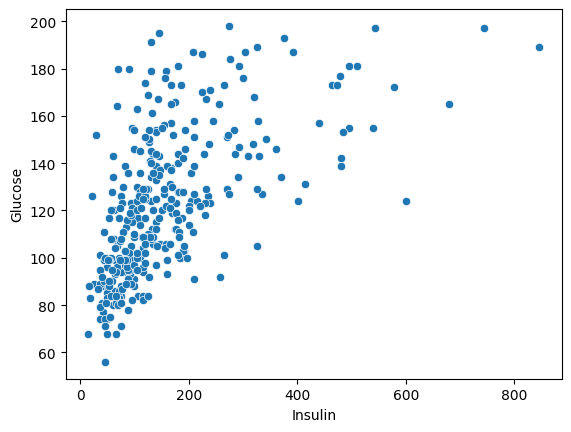

In [135]:
sns.scatterplot(x=df_t['Insulin'],y=df_t['Glucose'])

In [136]:
model2 = make_pipeline(PolynomialFeatures(2), LinearRegression())

In [137]:
model2.fit(X_train, y_train)

,steps,"[('polynomialfeatures', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,True
,order,'C'
,fit_intercept,True
,copy_X,True
,tol,1e-06


In [139]:
model2.score(X_test, y_test)

0.2835362094145243